# General overview of selected datasets for cross-analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import glob
import os
import sqlite3
import pickle
import warnings
warnings.filterwarnings("ignore")

## Integrating and querying the database from PhageExpressionAtlas for data access (gffs, count data, etc.)

- query for TPM_means for all datasets first

In [2]:
# Dataset identifiers to be selected

dataset_list = ['Wolfram-Schauerte_2022', 'Guegler_2021_T4_minus_toxIN', 'Guegler_2021_T4_plus_toxIN', 'Guegler_2021_T7_minus_toxIN',
                'Guegler_2021_T7_plus_toxIN', 'Finstrlova_2022_Newman', 'Finstrlova_2022_SH1000', 'Leskinen_2016', 'Brandão_2021_LB',
                'Lood_2020', 'Li_2020', 'Ceyssens_2014_directional', 'Kongari_2024_WT', 'Kongari_2024_rpoC-G17D', 'Silva_2024_exponential', 'Brandão_2021_MCCM',
                'McLaughlin_2023', 'Halleran_2015']

In [3]:
def get_datasets(db: str, normalization: str, dataset_list: list):
    """
    db: path to SQLite db
    entity: 'host' or 'phage'  (determines which table to use to query phage/host info)
    normalization: normalization string required in dataset table --> TPM_means, TPM values, log values
    dataset_list: list of dataset names to extract (name)
    """

    # Connect to the database
    connection = sqlite3.connect(db)

    # 1) Get datasets by:
    #    - matching normalization
    #    - matching dataset names from dataset_list
    
    dataset_name_placeholders = ",".join("?" * len(dataset_list))

    dataset_query = f"""
        SELECT *
        FROM dataset
        WHERE normalization = ?
          AND name IN ({dataset_name_placeholders})
    """

    dataset_params = [normalization] + dataset_list
    df_datasets = pd.read_sql_query(dataset_query, connection, params=dataset_params)

    if df_datasets.empty:
        print("No datasets matched your filters.")
        return df_datasets

    # 2) Get host & phage metadata for merging
    host_ids = [int(id) for id in list(df_datasets["host_id"].unique())]
    phage_ids = [int(id) for id in list(df_datasets["phage_id"].unique())]

    host_placeholders = ",".join("?" * len(host_ids))

    # Host
    host_query = (
        f'SELECT * '
        f'FROM host WHERE id IN ({host_placeholders})'
    )
    host_info = pd.read_sql_query(host_query, connection, params=host_ids)

    phage_placeholders = ",".join("?" * len(phage_ids))

    # Phage
    phage_query = (
        f"SELECT * "
        f"FROM phage WHERE id IN ({phage_placeholders})"
    )
    phage_info = pd.read_sql_query(phage_query, connection, params=phage_ids)

    # Merge all information in one dataframe
    merged = df_datasets.merge(host_info, left_on="host_id", right_on="id", how="left", suffixes=("", "_host"))
    merged = merged.merge(phage_info, left_on="phage_id", right_on="id", how="left", suffixes=("", "_phage"))

    return merged

In [4]:
df2 = get_datasets('../../PhageExpressionAtlas/instance/db.sqlite3', 'TPM_means', dataset_list)

In [5]:
df2.head()

,id,phage_id,host_id,matrix_data,normalization,name,journal,year,firstauthor,pubmedID,...,id_host,name_host,group,description_host,ncbi_id,id_phage,name_phage,description_phage,ncbi_id_phage,phage_type
0,3,1,1,b'\x80\x04\x95\x13\x01\x00\x00\x00\x00\x00\x00...,TPM_means,Wolfram-Schauerte_2022,Viruses,2022,Wolfram-Schauerte,36423111,...,1,E. coli B strain,Escherichia coli,E. coli K12 MG1655 reference,U00096.3,1,T4 phage,Bacteriophage T4,NC_000866.4,virulent
1,8,1,2,b'\x80\x04\x95\x13\x01\x00\x00\x00\x00\x00\x00...,TPM_means,Guegler_2021_T4_minus_toxIN,Molecular Cell,2021,Guegler,33838104,...,2,E. coli K 12 pBR322 empty,Escherichia coli,E. coli K12 MG1655 without toxIN expression,U00096.3,1,T4 phage,Bacteriophage T4,NC_000866.4,virulent
2,13,1,3,b'\x80\x04\x95\x13\x01\x00\x00\x00\x00\x00\x00...,TPM_means,Guegler_2021_T4_plus_toxIN,Molecular Cell,2021,Guegler,33838104,...,3,E. coli K 12 pBR322-toxIN,Escherichia coli,E. coli K12 MG1655 expressing toxIN,U00096.3,1,T4 phage,Bacteriophage T4,NC_000866.4,virulent
3,18,2,2,b'\x80\x04\x95\x13\x01\x00\x00\x00\x00\x00\x00...,TPM_means,Guegler_2021_T7_minus_toxIN,Molecular Cell,2021,Guegler,33838104,...,2,E. coli K 12 pBR322 empty,Escherichia coli,E. coli K12 MG1655 without toxIN expression,U00096.3,2,T7 phage,Bacteriophage T7,NC_001604.1,virulent
4,23,2,3,b'\x80\x04\x95\x13\x01\x00\x00\x00\x00\x00\x00...,TPM_means,Guegler_2021_T7_plus_toxIN,Molecular Cell,2021,Guegler,33838104,...,3,E. coli K 12 pBR322-toxIN,Escherichia coli,E. coli K12 MG1655 expressing toxIN,U00096.3,2,T7 phage,Bacteriophage T7,NC_001604.1,virulent


In [6]:
# Extract (unpickle) dataframe and gather in list
data = []
for row in df2.index.tolist():
    col = df2.loc[row, 'matrix_data']
    df_work = pickle.loads(col)
    df_work.drop(['ClassThreshold', 'ClassMax', 'Variance'], axis = 1, inplace=True)
    df_work[['dataset_name', 'phage', 'host', 'host_species', 'phage_ncbi', 'host_ncbi']] = df2.loc[row, ['name', 'name_phage', 'name_host', 'group', 'ncbi_id_phage', 'ncbi_id']]
    data.append(df_work)

data[0]

,0,1,4,7,20,Entity,Symbol,dataset_name,phage,host,host_species,phage_ncbi,host_ncbi
Geneid,,,,,,,,,,,,,
gene-b3271,3.854216,3.508696,0.685155,0.276659,0.148276,host,yhdZ,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b3825,89.126916,92.629824,11.832511,5.775497,3.374411,host,pldB,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b1101,1178.944342,1089.750703,224.701106,90.627614,55.606633,host,ptsG,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b3842,52.327743,79.035229,17.849993,6.604012,3.477209,host,rfaH,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b4544,128.185385,122.654385,19.922151,8.562299,4.701841,host,arnE,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-b3828,10.861747,7.289015,1.787324,0.945102,0.906726,host,metR,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b3072,6.991692,6.196106,1.356657,0.634771,0.397032,host,aer,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3
gene-b4233,120.143114,106.409115,24.998774,9.709781,5.973668,host,mpl,Wolfram-Schauerte_2022,T4 phage,E. coli B strain,Escherichia coli,NC_000866.4,U00096.3


## Plotting distribution of transcripts per host and phage across datasets and time course of infection

In [7]:
def entity_comparison_barplots(df_list, entity_col="Entity"):
    """
    For each dataframe in df_list:
      - Split by Entity (expects values 'host' and 'phage')
      - Sum numeric columns for each entity
      - Compute percentage contribution of phage and host per column
      - Plot stacked barplot comparing host vs phage for each numeric column
    """

    for i, df in enumerate(df_list, start=1):
        # Select only numeric columns
        print(str(df['dataset_name'].unique()))
        dataset_name = str(df['dataset_name'].unique())
        numeric_cols = df.select_dtypes(include='number').columns.tolist()
        if not numeric_cols:
            print(f"Skipping df {i}: no numeric columns")
            continue
        
        # Ensure entity column exists
        if entity_col not in df.columns:
            print(f"Skipping df {i}: '{entity_col}' column not found")
            continue

        # Group and sum
        grouped = df.groupby(entity_col)[numeric_cols].sum()

        # Only keep phage and host if present
        grouped = grouped.loc[grouped.index.intersection(['phage', 'host'])]

        if grouped.shape[0] < 2:
            print(f"Skipping df {i}: missing phage or host in {entity_col}")
            continue

        # Calculate percentages per column
        perc = grouped.div(grouped.sum(axis=0), axis=1) * 100
        perc = perc.T

        # Plot
        plt.figure(figsize=(8, 5))
        perc.plot(kind="bar", stacked=True, color=["#1f77b4", "#ff7f0e"])
        plt.title(f"Entity comparison {dataset_name}")
        plt.ylabel("Percentage TPM mean contribution (%)")
        plt.xlabel("Time point post infection")
        plt.xticks(rotation=90)
        plt.legend(title=entity_col, loc="center left", bbox_to_anchor=(1.02, 0.5))
        plt.tight_layout()
        plt.show()

['Wolfram-Schauerte_2022']


<Figure size 800x500 with 0 Axes>

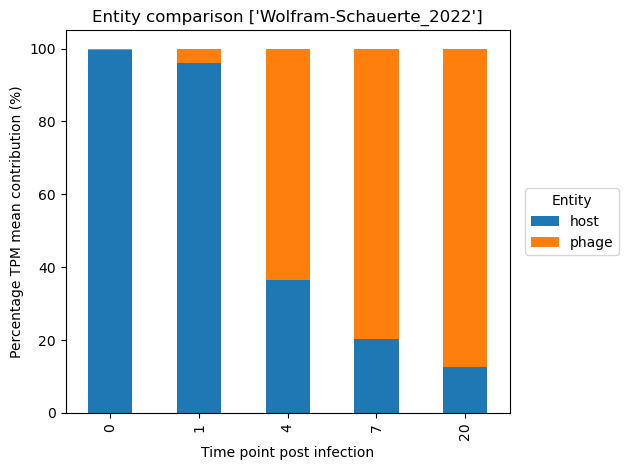

['Guegler_2021_T4_minus_toxIN']


<Figure size 800x500 with 0 Axes>

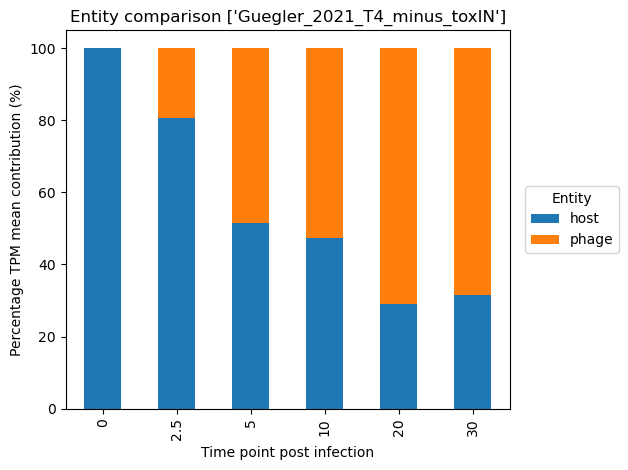

['Guegler_2021_T4_plus_toxIN']


<Figure size 800x500 with 0 Axes>

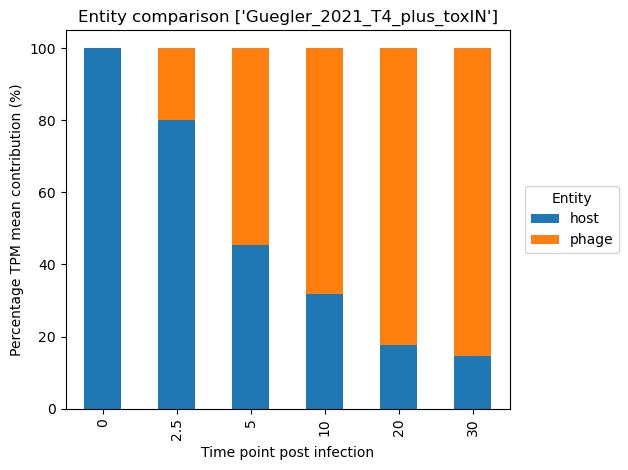

['Guegler_2021_T7_minus_toxIN']


<Figure size 800x500 with 0 Axes>

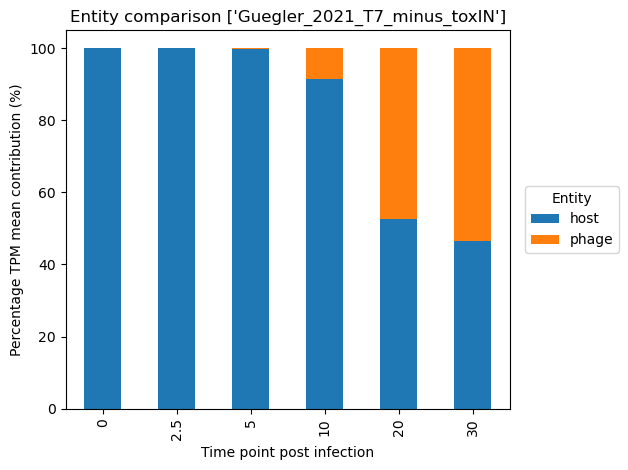

['Guegler_2021_T7_plus_toxIN']


<Figure size 800x500 with 0 Axes>

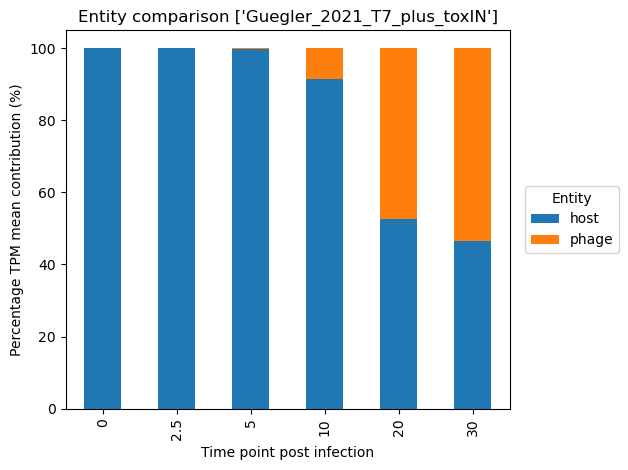

['Finstrlova_2022_Newman']


<Figure size 800x500 with 0 Axes>

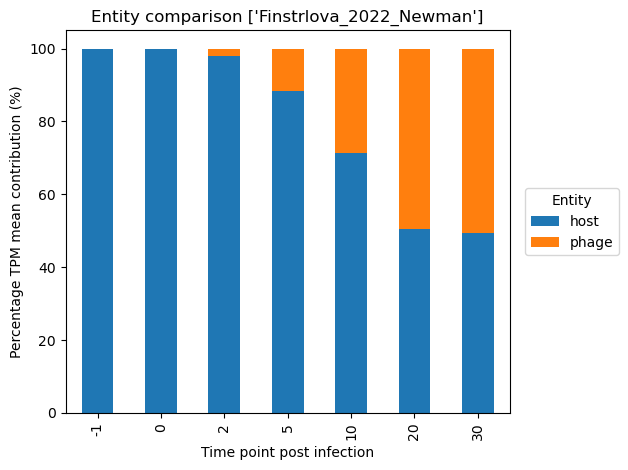

['Finstrlova_2022_SH1000']


<Figure size 800x500 with 0 Axes>

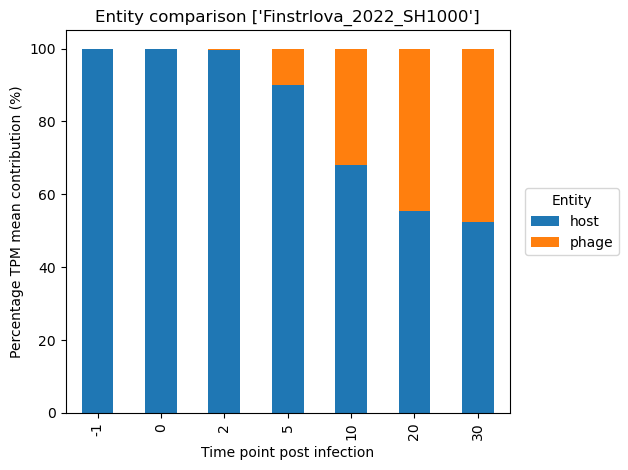

['Leskinen_2016']


<Figure size 800x500 with 0 Axes>

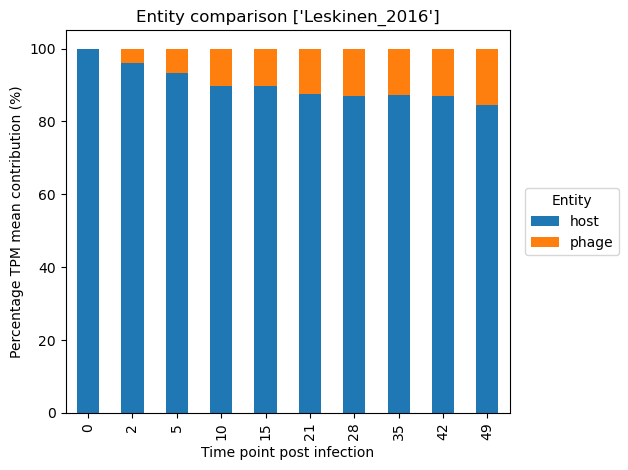

['Brandão_2021_LB']


<Figure size 800x500 with 0 Axes>

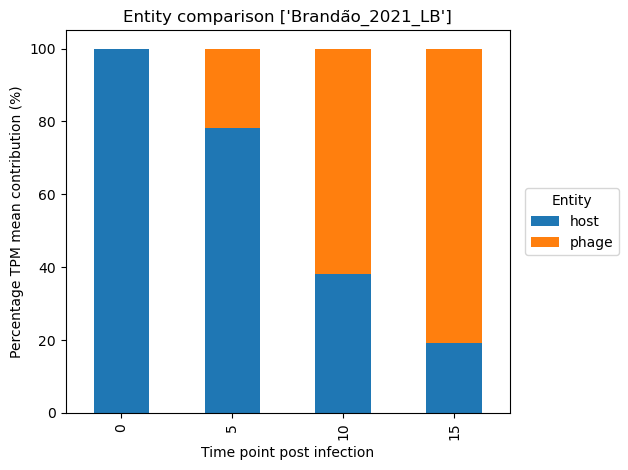

['Brandão_2021_MCCM']


<Figure size 800x500 with 0 Axes>

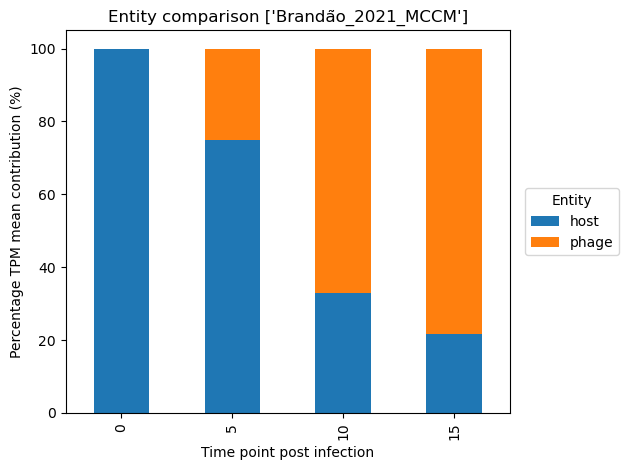

['Lood_2020']


<Figure size 800x500 with 0 Axes>

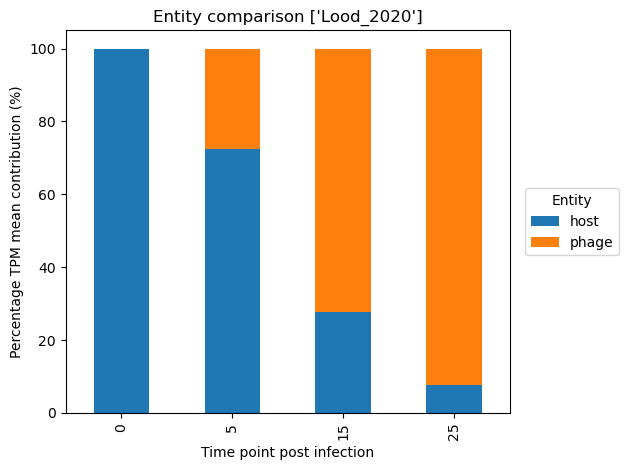

['Li_2020']


<Figure size 800x500 with 0 Axes>

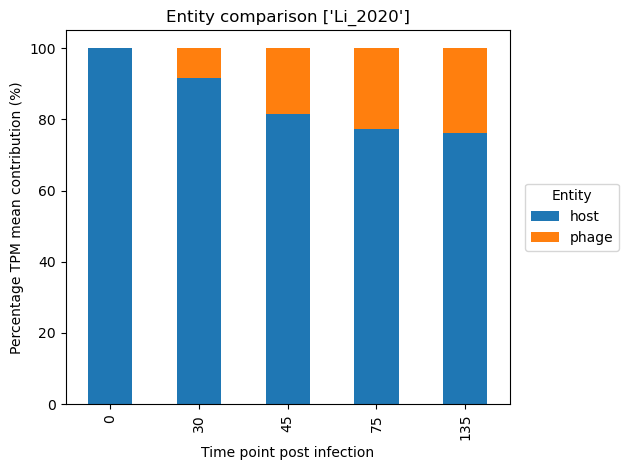

['Ceyssens_2014_directional']


<Figure size 800x500 with 0 Axes>

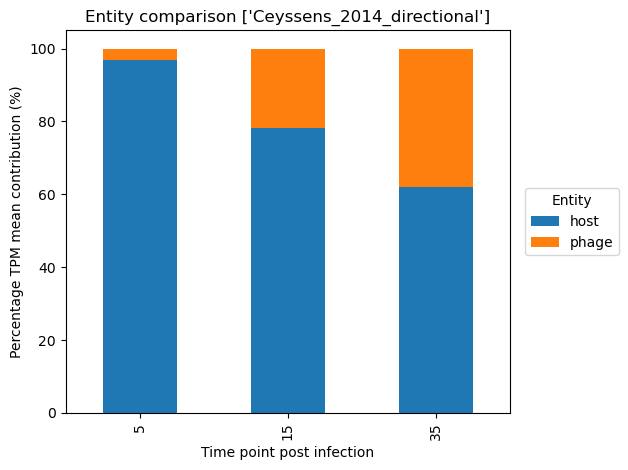

['Kongari_2024_WT']


<Figure size 800x500 with 0 Axes>

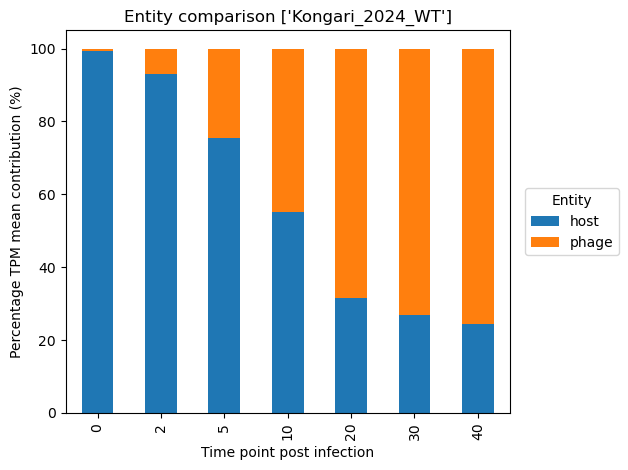

['Kongari_2024_rpoC-G17D']


<Figure size 800x500 with 0 Axes>

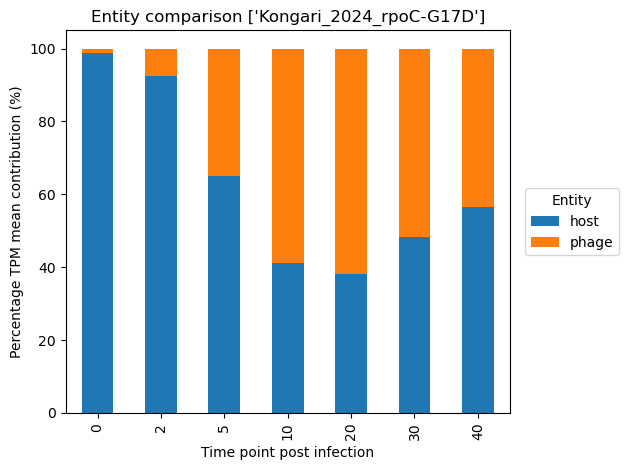

['Silva_2024_exponential']


<Figure size 800x500 with 0 Axes>

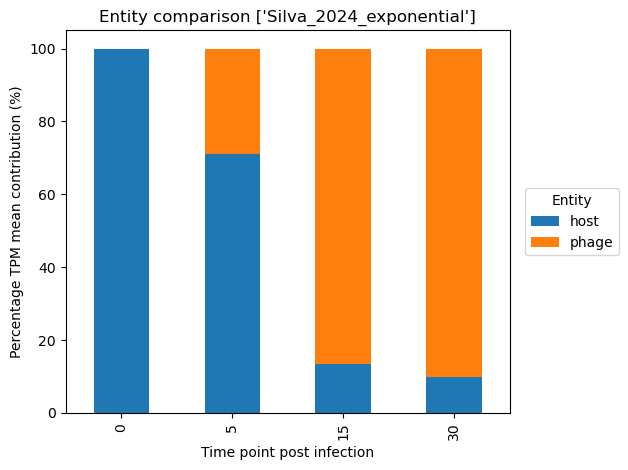

['McLaughlin_2023']


<Figure size 800x500 with 0 Axes>

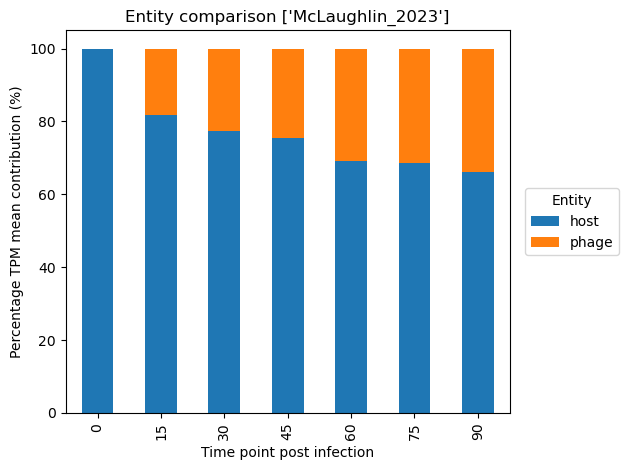

['Halleran_2015']


<Figure size 800x500 with 0 Axes>

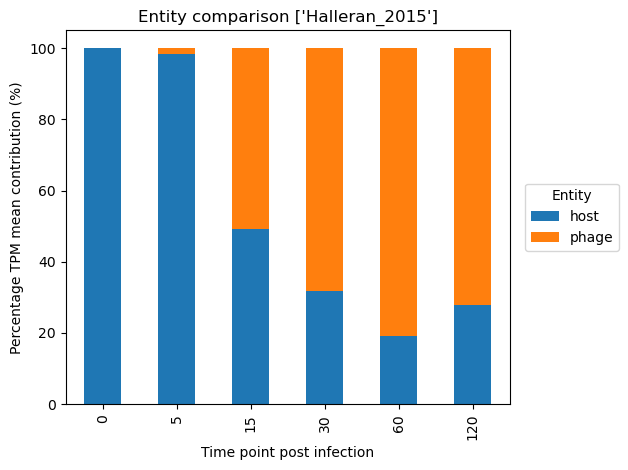

In [8]:
entity_comparison_barplots(data, "Entity")

In [9]:
# Checks for float
def is_float(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

# Edit df
def edit_df(df):

    # Copy df
    df_new = df.copy()

    # Drop -1 columns
    if '-1' in df_new.columns:
        df_new = df_new.drop(['-1'], axis=1)
    
    # Change timepoints to relative ones
    t_cols = [c for c in df_new.columns if is_float(str(c))]
    t_cols_float = [float(c) for c in t_cols]
    t_max = max(t_cols_float)
    new_cols = [x / t_max for x in t_cols_float]
    col_dct = {orig: rel for orig, rel in zip(t_cols, new_cols)}
    df_new = df_new.rename(columns=col_dct)
    return df_new

def entity_comparison_barplots(df_list, entity_col="Entity"):
    """
    For each dataframe in df_list:
      - Split by Entity (expects values 'host' and 'phage')
      - Sum numeric columns for each entity
      - Compute percentage contribution of phage and host per column
      - Plot stacked barplot comparing host vs phage for each numeric column
    """

    for i, df in enumerate(df_list, start=1):
        # Select only numeric columns
        print(str(df['dataset_name'].unique()))
        dataset_name = str(df['dataset_name'].unique())

        df = edit_df(df)

        numeric_cols = df.select_dtypes(include='number').columns.tolist()
        if not numeric_cols:
            print(f"Skipping df {i}: no numeric columns")
            continue
        
        # Ensure entity column exists
        if entity_col not in df.columns:
            print(f"Skipping df {i}: '{entity_col}' column not found")
            continue

        # Group and sum
        grouped = df.groupby(entity_col)[numeric_cols].sum()

        # Only keep phage and host if present
        grouped = grouped.loc[grouped.index.intersection(['phage', 'host'])]

        if grouped.shape[0] < 2:
            print(f"Skipping df {i}: missing phage or host in {entity_col}")
            continue

        # Calculate percentages per column
        perc = grouped.div(grouped.sum(axis=0), axis=1) * 100

        perc = perc.T

        # Plot
        x = perc.index.values
        width = (x[1] - x[0]) * 0.8 

        plt.figure(figsize=(8, 5))
        plt.bar(x, perc.iloc[:, 0], width=width, label=perc.columns[0], color="#1f77b4")
        plt.bar(x, perc.iloc[:, 1], width=width, bottom=perc.iloc[:, 0], 
                label=perc.columns[1], color="#ff7f0e")
        
        plt.title(f"Entity comparison {dataset_name}")
        plt.ylabel("Percentage TPM mean contribution (%)")
        plt.xlabel("Time point post infection")
        plt.xticks(rotation=0, ha="center")
        plt.legend(title=entity_col, loc="center left", bbox_to_anchor=(1.02, 0.5))
        plt.tight_layout()
        plt.show()

['Wolfram-Schauerte_2022']


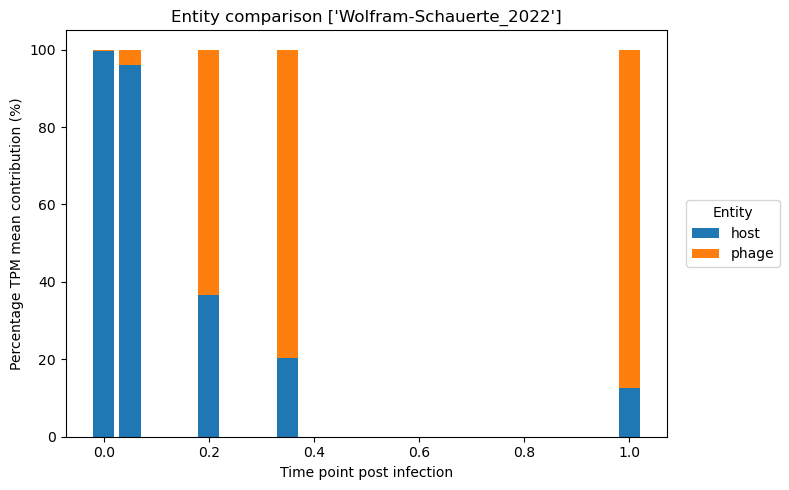

['Guegler_2021_T4_minus_toxIN']


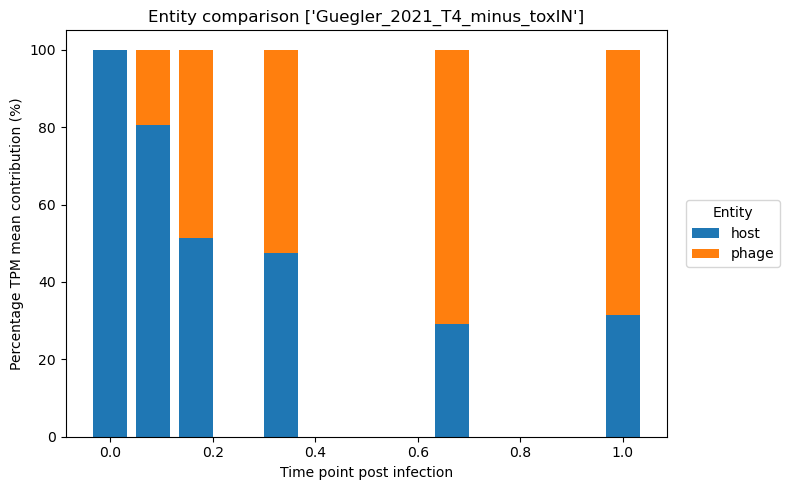

['Guegler_2021_T4_plus_toxIN']


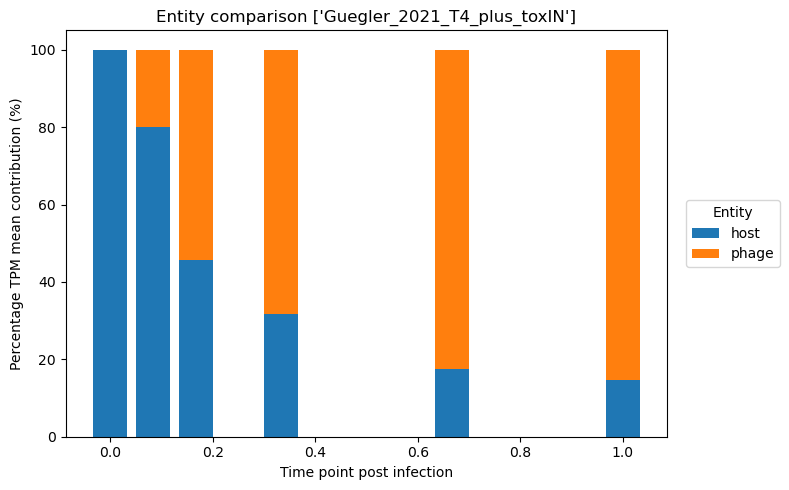

['Guegler_2021_T7_minus_toxIN']


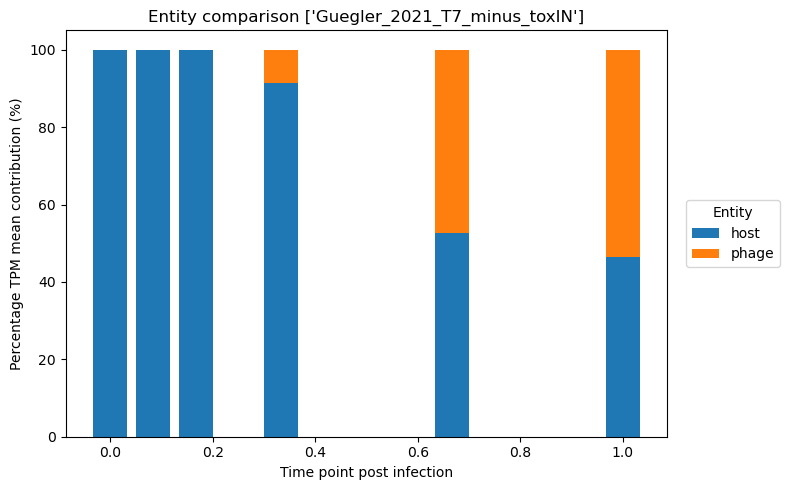

['Guegler_2021_T7_plus_toxIN']


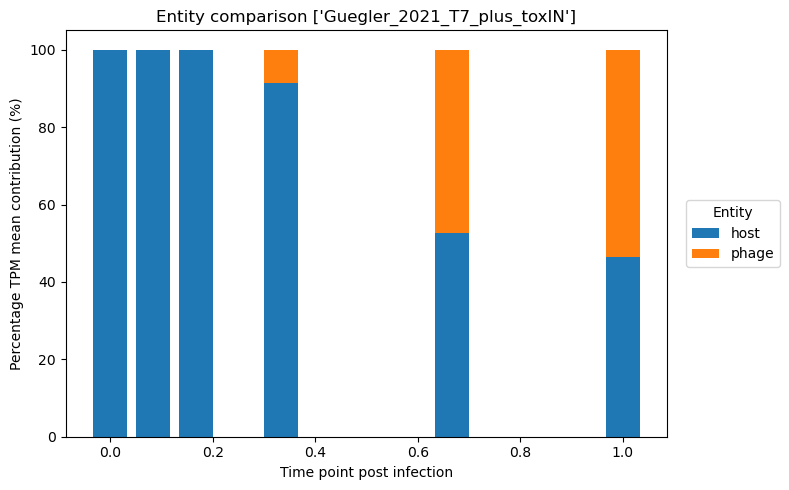

['Finstrlova_2022_Newman']


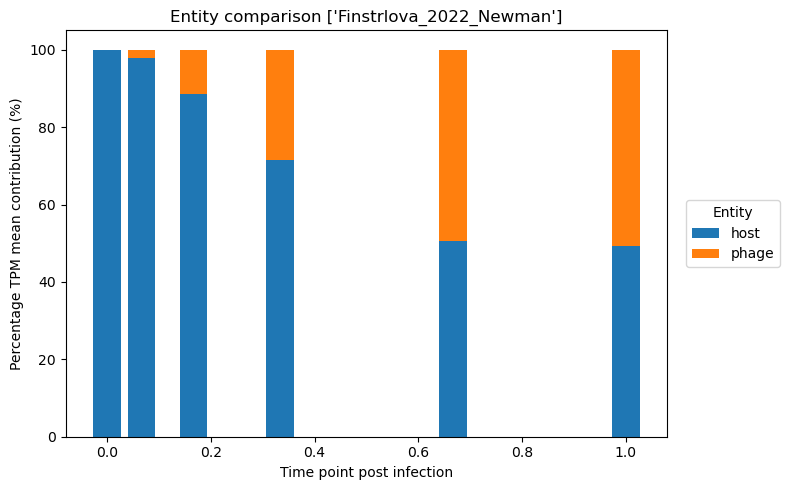

['Finstrlova_2022_SH1000']


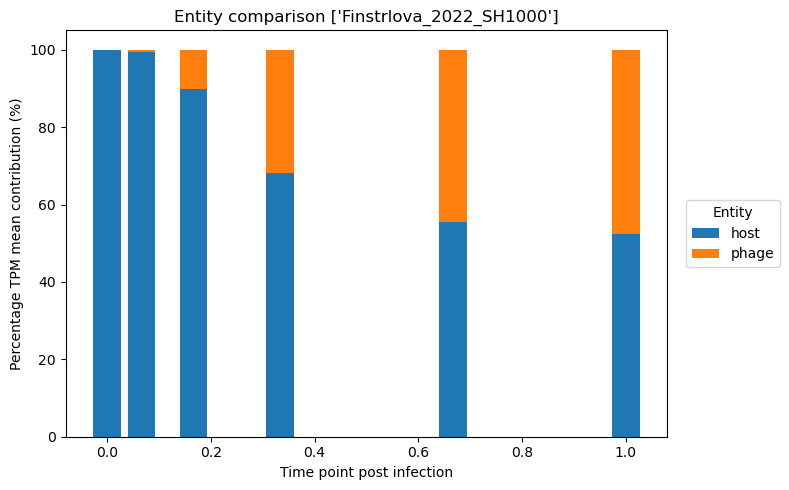

['Leskinen_2016']


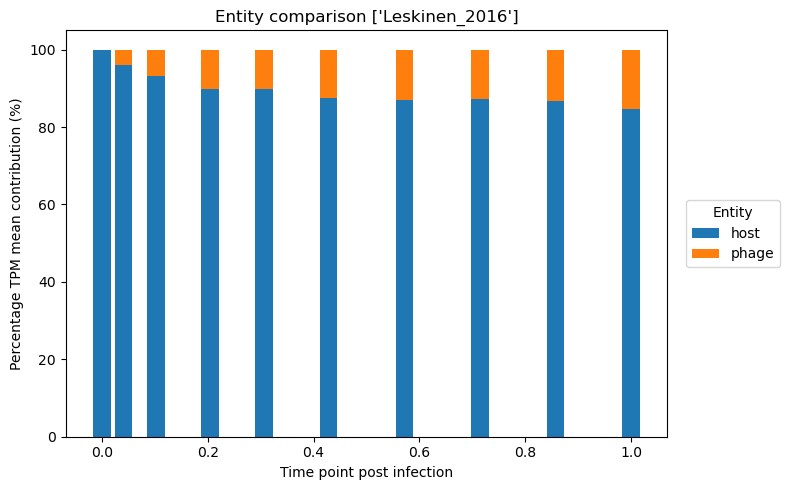

['Brandão_2021_LB']


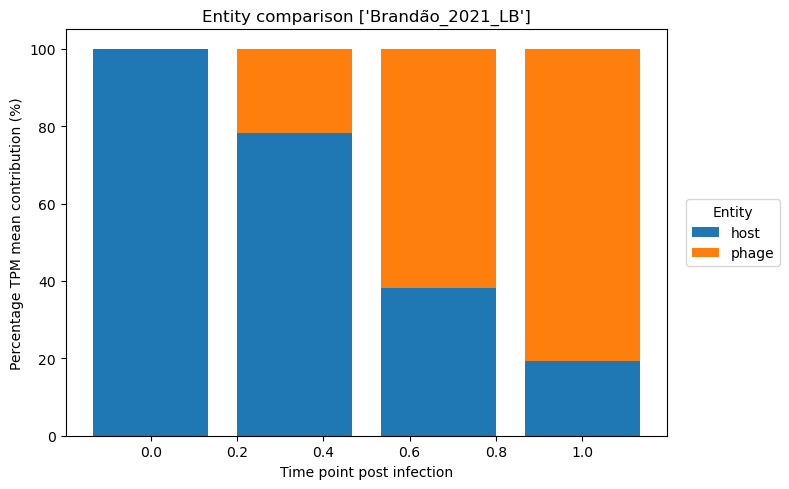

['Brandão_2021_MCCM']


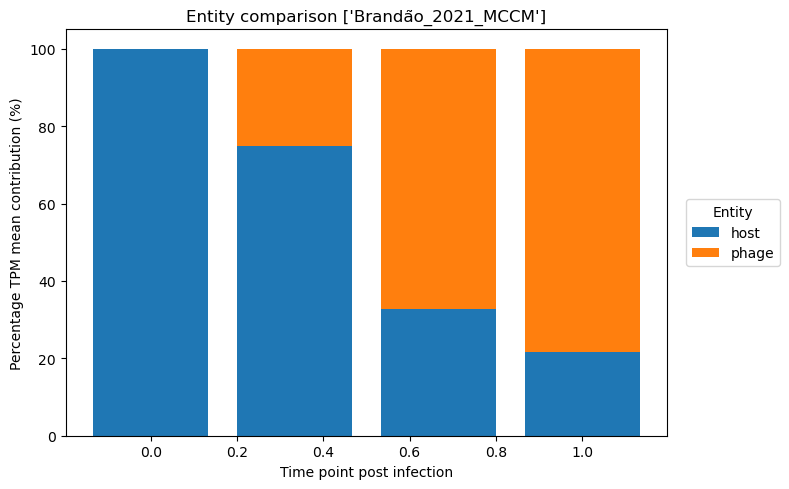

['Lood_2020']


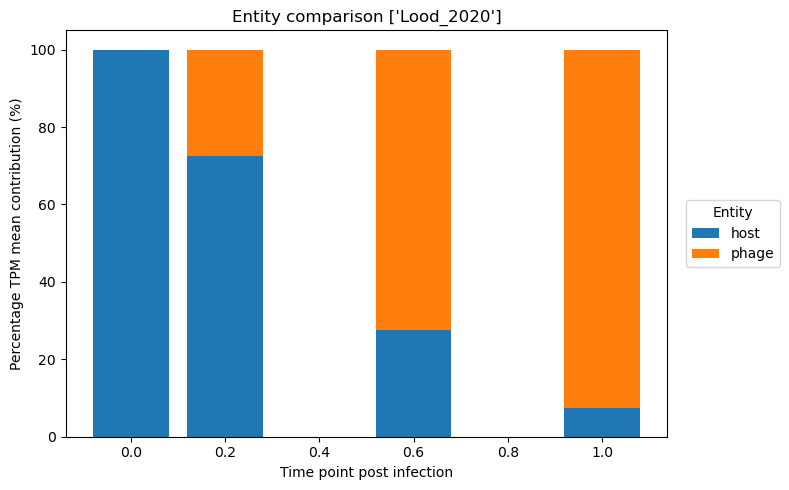

['Li_2020']


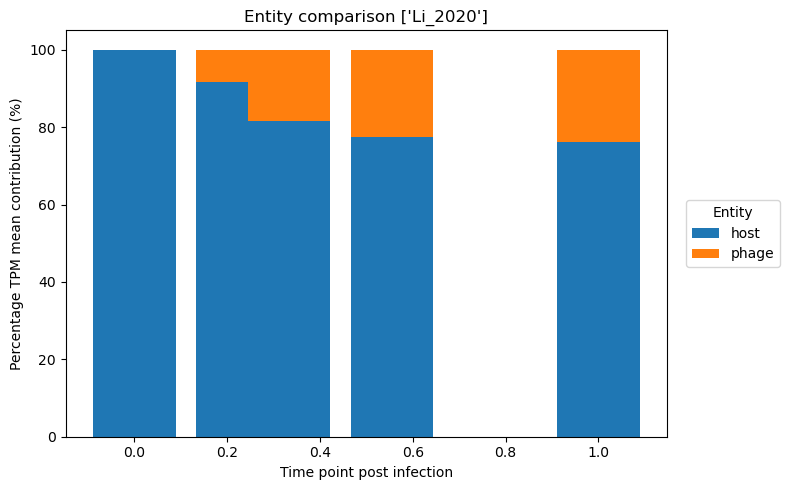

['Ceyssens_2014_directional']


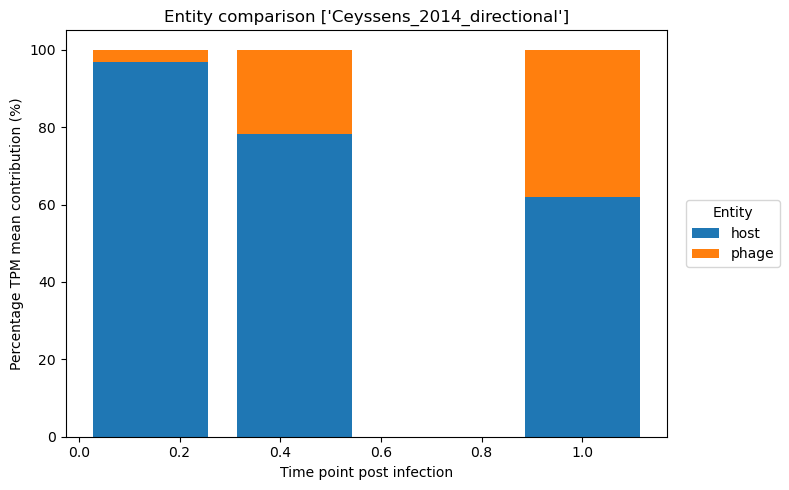

['Kongari_2024_WT']


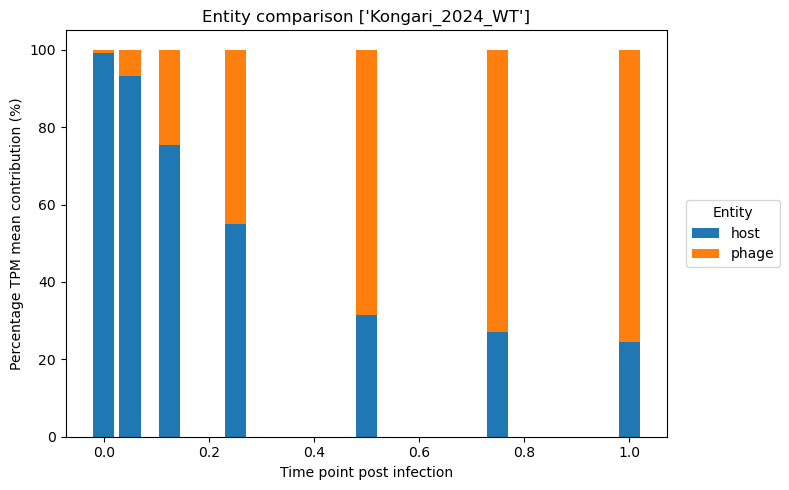

['Kongari_2024_rpoC-G17D']


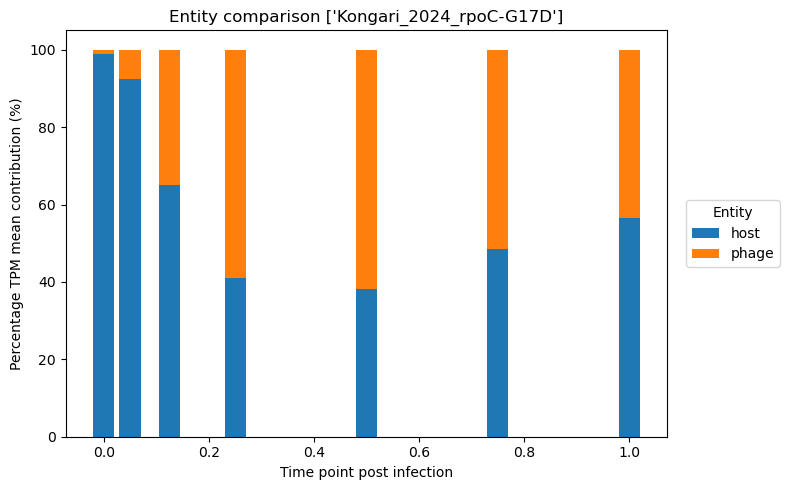

['Silva_2024_exponential']


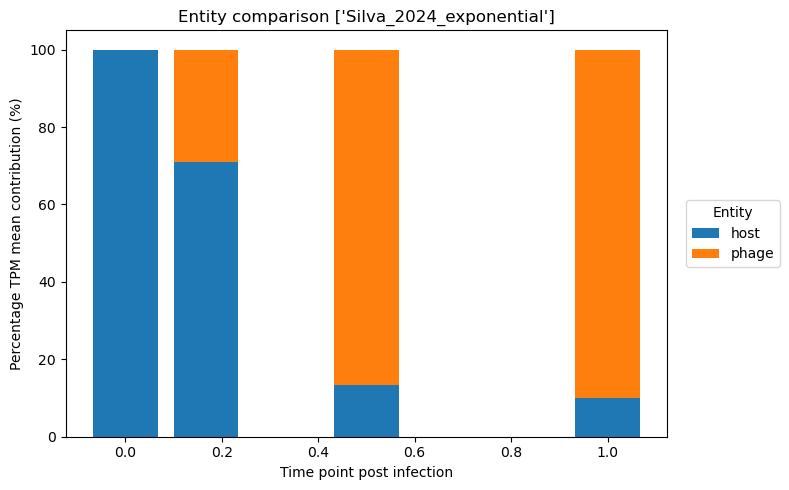

['McLaughlin_2023']


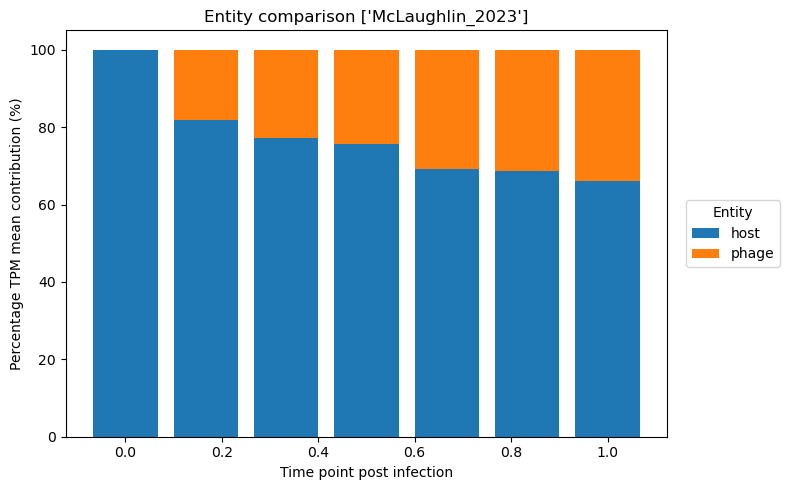

['Halleran_2015']


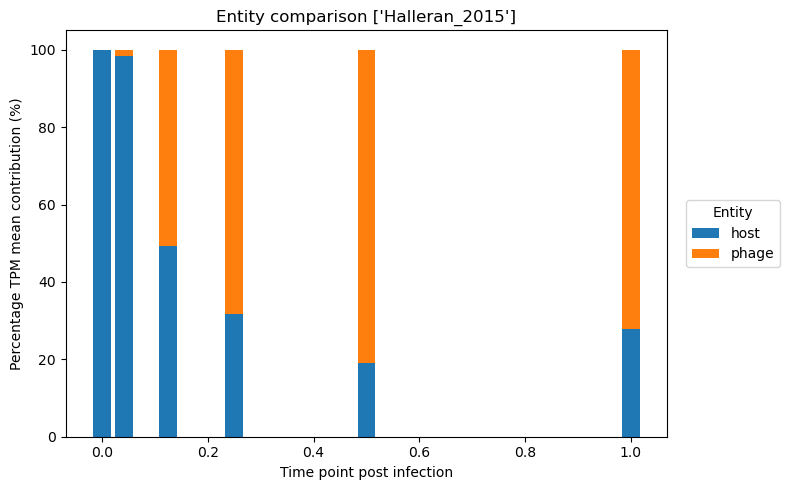

In [10]:
entity_comparison_barplots(data)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def combined_entity_summary(df_list, entity_col="Entity",
                            n_points=200,  # resolution of resampling grid (0–1)
                            ci="sd",        # "sd" or "sem"
                            figsave=False
):
    """
    Combine all datasets into one host/phage TPM percentage summary plot
    with confidence intervals across relative time (0–1).

    Steps:
      1. Normalize timepoints in every df
      2. Compute host/phage percentages within each df
      3. Interpolate onto a shared relative time grid
      4. Compute mean + SD or SEM across datasets
      5. Plot mean ± CI ribbons
    """

    all_host = []
    all_phage = []
    grid = np.linspace(0, 1, n_points)

    for df in df_list:
        df2 = edit_df(df)

        # numeric time columns
        t_cols = [c for c in df2.columns if is_float(str(c))]
        if not t_cols:
            continue
        
        numeric_cols = [float(c) for c in t_cols]

        # Entity check
        if entity_col not in df2.columns:
            continue

        grouped = df2.groupby(entity_col)[t_cols].sum()
        if not {"host", "phage"}.issubset(grouped.index):
            continue
        
        # Convert to percentages
        total = grouped.loc["host"] + grouped.loc["phage"]
        host_pct = grouped.loc["host"] / total * 100
        phage_pct = grouped.loc["phage"] / total * 100

        # Interpolate to common grid
        xs = np.array([float(x) for x in host_pct.index])
        idx = np.argsort(xs)
        xs = xs[idx]

        host_y = host_pct.values[idx]
        phage_y = phage_pct.values[idx]

        f_host = interp1d(xs, host_y, fill_value="extrapolate")
        f_phage = interp1d(xs, phage_y, fill_value="extrapolate")

        all_host.append(f_host(grid))
        all_phage.append(f_phage(grid))

    # Convert to arrays
    H = np.vstack(all_host)
    P = np.vstack(all_phage)

    # Compute mean + CI
    host_mean = H.mean(axis=0)
    phage_mean = P.mean(axis=0)

    if ci == "sd":
        host_ci = H.std(axis=0)
        phage_ci = P.std(axis=0)
    elif ci == "sem":
        host_ci = H.std(axis=0) / np.sqrt(H.shape[0])
        phage_ci = P.std(axis=0) / np.sqrt(P.shape[0])

    # Generate plot
    plt.figure(figsize=(10, 6))

    # Lane for host
    plt.plot(grid, host_mean, label="Host", color="#1f77b4")
    plt.fill_between(grid, host_mean - host_ci, host_mean + host_ci,
                     color="#1f77b4", alpha=0.25)

    # Lane for phage
    plt.plot(grid, phage_mean, label="Phage", color="#ff7f0e")
    plt.fill_between(grid, phage_mean - phage_ci, phage_mean + phage_ci,
                     color="#ff7f0e", alpha=0.25)

    plt.xlabel("Relative time (0–1)")
    plt.ylabel("Percentage TPM contribution (%)")
    plt.title("Combined Host vs Phage TPM Percentage Across Datasets")
    plt.legend()
    plt.tight_layout()
    if figsave:
        plt.savefig("Count_distribution.svg")
    plt.show()

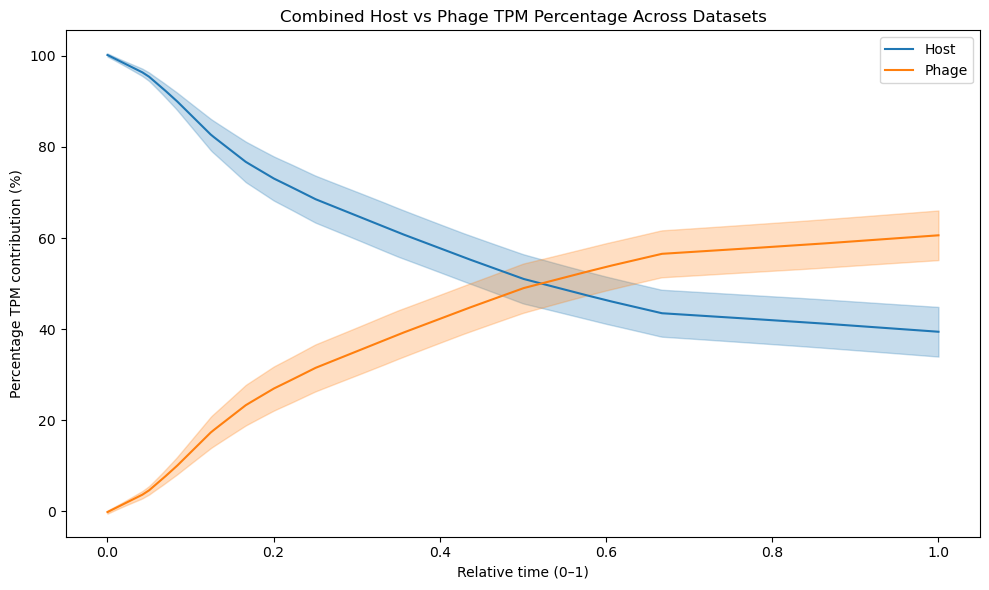

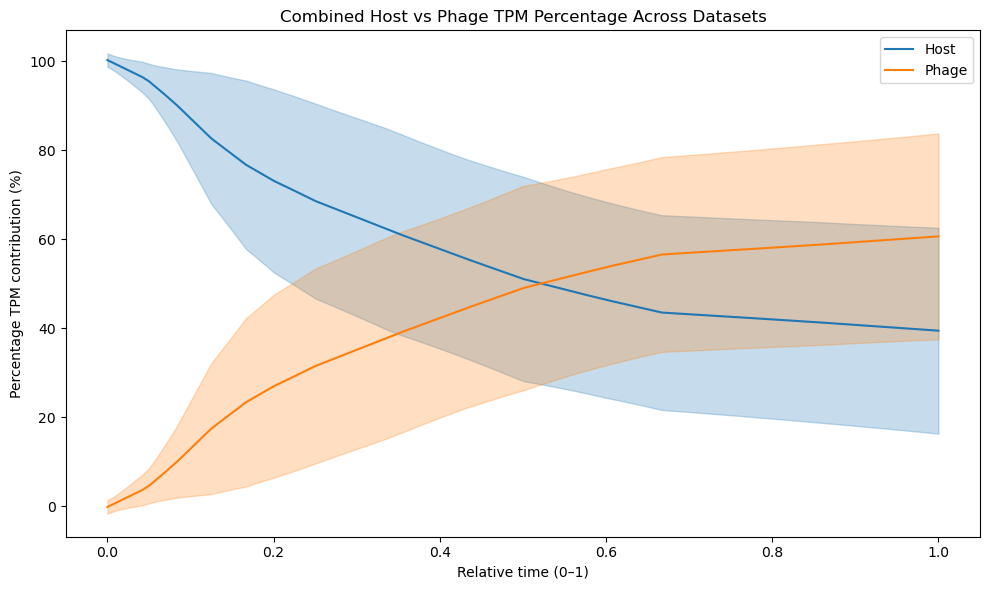

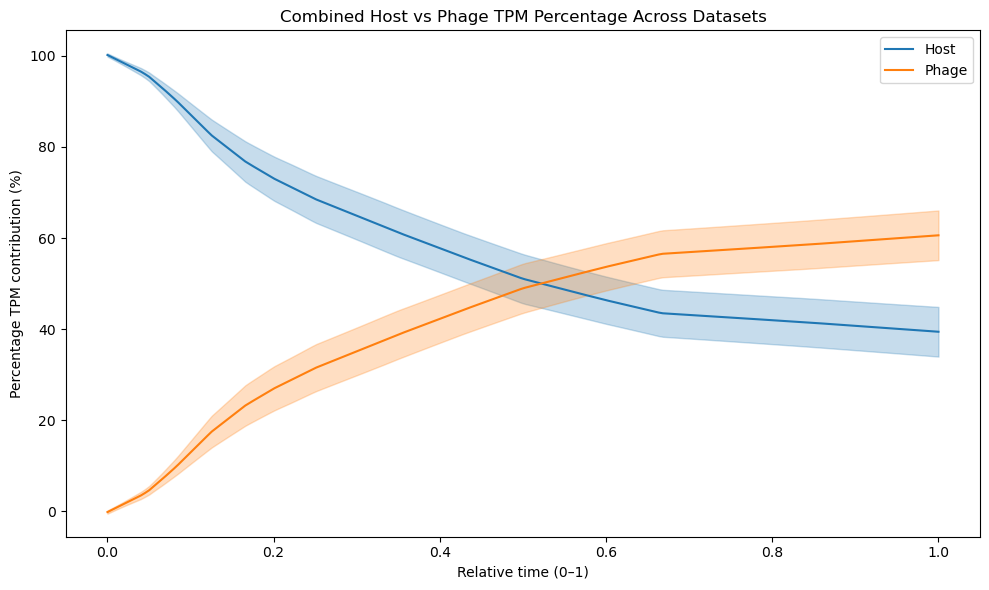

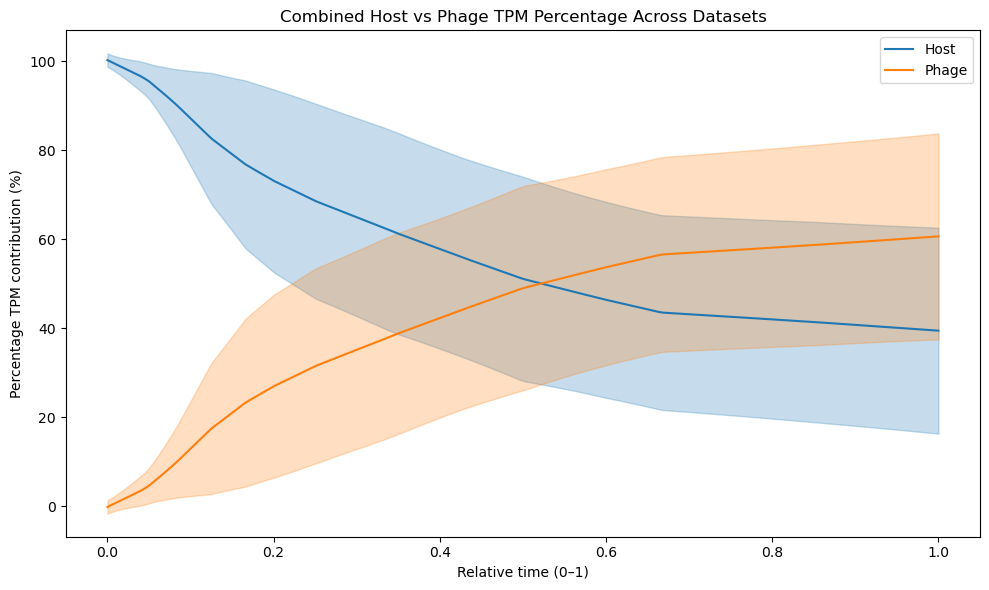

In [12]:
combined_entity_summary(data, n_points=500, ci="sem")
combined_entity_summary(data, n_points=500)
combined_entity_summary(data, ci="sem")
combined_entity_summary(data)

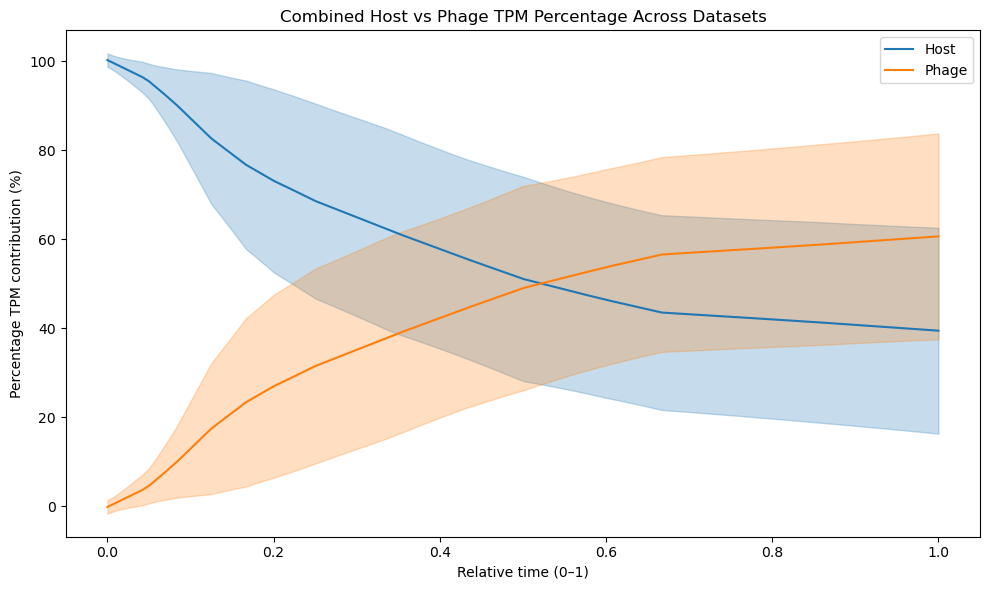

In [13]:
# Save plot as svg, using sd for confidence interval

combined_entity_summary(data, n_points=500,figsave=True)